# 🧠 Explainable Neuro-Symbolic Framework for Customer Churn Prediction in Online Retail

**Dataset:** E-Commerce Customer Insights and Churn Dataset  
**Target Variable:** `subscription_status` → Binary Churn Label (`churned` vs `active`)  
**Framework:** Neural Network + Symbolic Rules + SHAP Explainability

---

### 📌 Framework Overview
```
Raw Data → Feature Engineering → Symbolic Rule Extraction →
Neural Network (MLP) → SHAP Explanations → Hybrid Decision Logic
```

| Component | Role |
|---|---|
| **Neural Module** | Learns non-linear patterns (MLP Classifier) |
| **Symbolic Module** | Encodes domain rules (if-then logic from Decision Trees) |
| **Explainability** | SHAP + LIME to explain individual & global predictions |

## ⚙️ 1. Install & Import Libraries

In [7]:
# Install required libraries
!pip install shap lime scikit-learn pandas numpy matplotlib seaborn plotly --quiet

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, accuracy_score
)
from sklearn.inspection import permutation_importance

# Explainability
import shap
from lime.lime_tabular import LimeTabularExplainer

# Style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
COLORS = {'active': '#2ecc71', 'churned': '#e74c3c', 'paused': '#f39c12'}

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


## 📂 2. Data Loading & Initial Inspection

In [9]:
# Upload from your local machine (Google Colab)
from google.colab import files
uploaded = files.upload()  # Upload: E_Commerce_Customer_Insights_and_Churn_Dataset.csv

df = pd.read_csv('E Commerce Customer Insights and Churn Dataset (2).csv')
print(f'📊 Dataset Shape: {df.shape}')
print(f'📋 Columns: {list(df.columns)}')
df.head()

Saving E Commerce Customer Insights and Churn Dataset.csv to E Commerce Customer Insights and Churn Dataset (4).csv
📊 Dataset Shape: (2000, 17)
📋 Columns: ['order_id', 'customer_id', 'age', 'product_id', 'country', 'signup_date', 'last_purchase_date', 'cancellations_count', 'subscription_status', 'order_date', 'unit_price', 'quantity', 'purchase_frequency', 'preferred_category', 'product_name', 'category', 'gender']


,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
0,ORD5000,CUST1000,39,PROD200,Canada,1/7/2021,2/21/2023,0,active,8/20/2024,78.21,5,37,Sports,Football,Sports,Female
1,ORD5001,CUST1001,61,PROD201,USA,10/19/2020,12/8/2021,0,active,7/17/2025,64.02,8,35,Sports,Refrigerator,Home,Female
2,ORD5002,CUST1002,26,PROD202,Pakistan,6/10/2023,9/4/2023,3,cancelled,3/12/2025,604.14,2,44,Electronics,Hoodie,Clothing,Female
3,ORD5003,CUST1003,54,PROD203,India,7/30/2023,2/20/2024,4,paused,9/19/2024,84.66,4,1,Sports,Conditioner,Beauty,Male
4,ORD5004,CUST1004,50,PROD204,India,12/9/2020,9/14/2024,0,active,8/8/2024,62.66,7,35,Sports,Smartwatch,Electronics,Male


In [10]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Distribution ===')
print(df['subscription_status'].value_counts())
print('\n=== Basic Statistics ===')
df.describe().round(2)

=== Data Types ===
order_id                object
customer_id             object
age                      int64
product_id              object
country                 object
signup_date             object
last_purchase_date      object
cancellations_count      int64
subscription_status     object
order_date              object
unit_price             float64
quantity                 int64
purchase_frequency       int64
preferred_category      object
product_name            object
category                object
gender                  object
dtype: object

=== Missing Values ===
order_id               0
customer_id            0
age                    0
product_id             0
country                0
signup_date            0
last_purchase_date     0
cancellations_count    0
subscription_status    0
order_date             0
unit_price             0
quantity               0
purchase_frequency     0
preferred_category     0
product_name           0
category               0
gender          

,age,cancellations_count,unit_price,quantity,purchase_frequency
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,44.08,2.44,324.72,4.95,25.16
std,14.80,1.70,361.55,2.56,14.16
min,18.00,0.00,2.85,1.00,1.00
25%,31.00,1.00,111.13,3.00,13.00
50%,45.00,2.00,206.52,5.00,25.00
75%,57.00,4.00,384.51,7.00,37.00
max,69.00,5.00,1991.63,9.00,49.00


## 🔍 3. Exploratory Data Analysis (EDA)

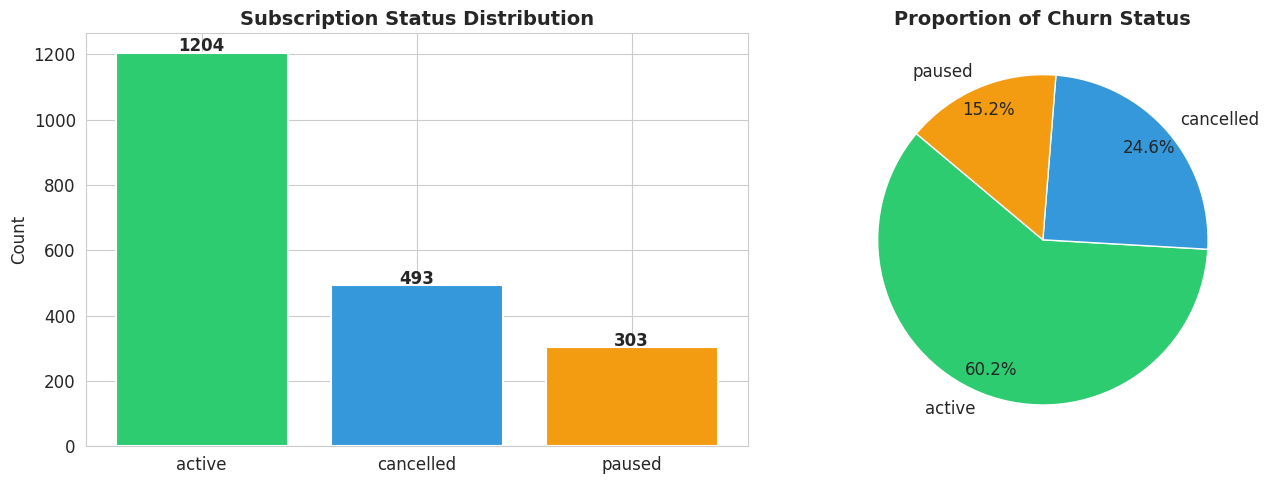


Churn Rate (cancelled): 24.6%
Paused Rate: 15.2%


In [11]:
# ── 3.1 Churn Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['subscription_status'].value_counts()
colors = [COLORS.get(x, '#3498db') for x in counts.index]

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Subscription Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(counts.items()):
    axes[0].text(i, val + 5, str(val), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140, pctdistance=0.85)
axes[1].set_title('Proportion of Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nChurn Rate (cancelled): {counts["cancelled"]/len(df)*100:.1f}%')
print(f'Paused Rate: {counts["paused"]/len(df)*100:.1f}%')

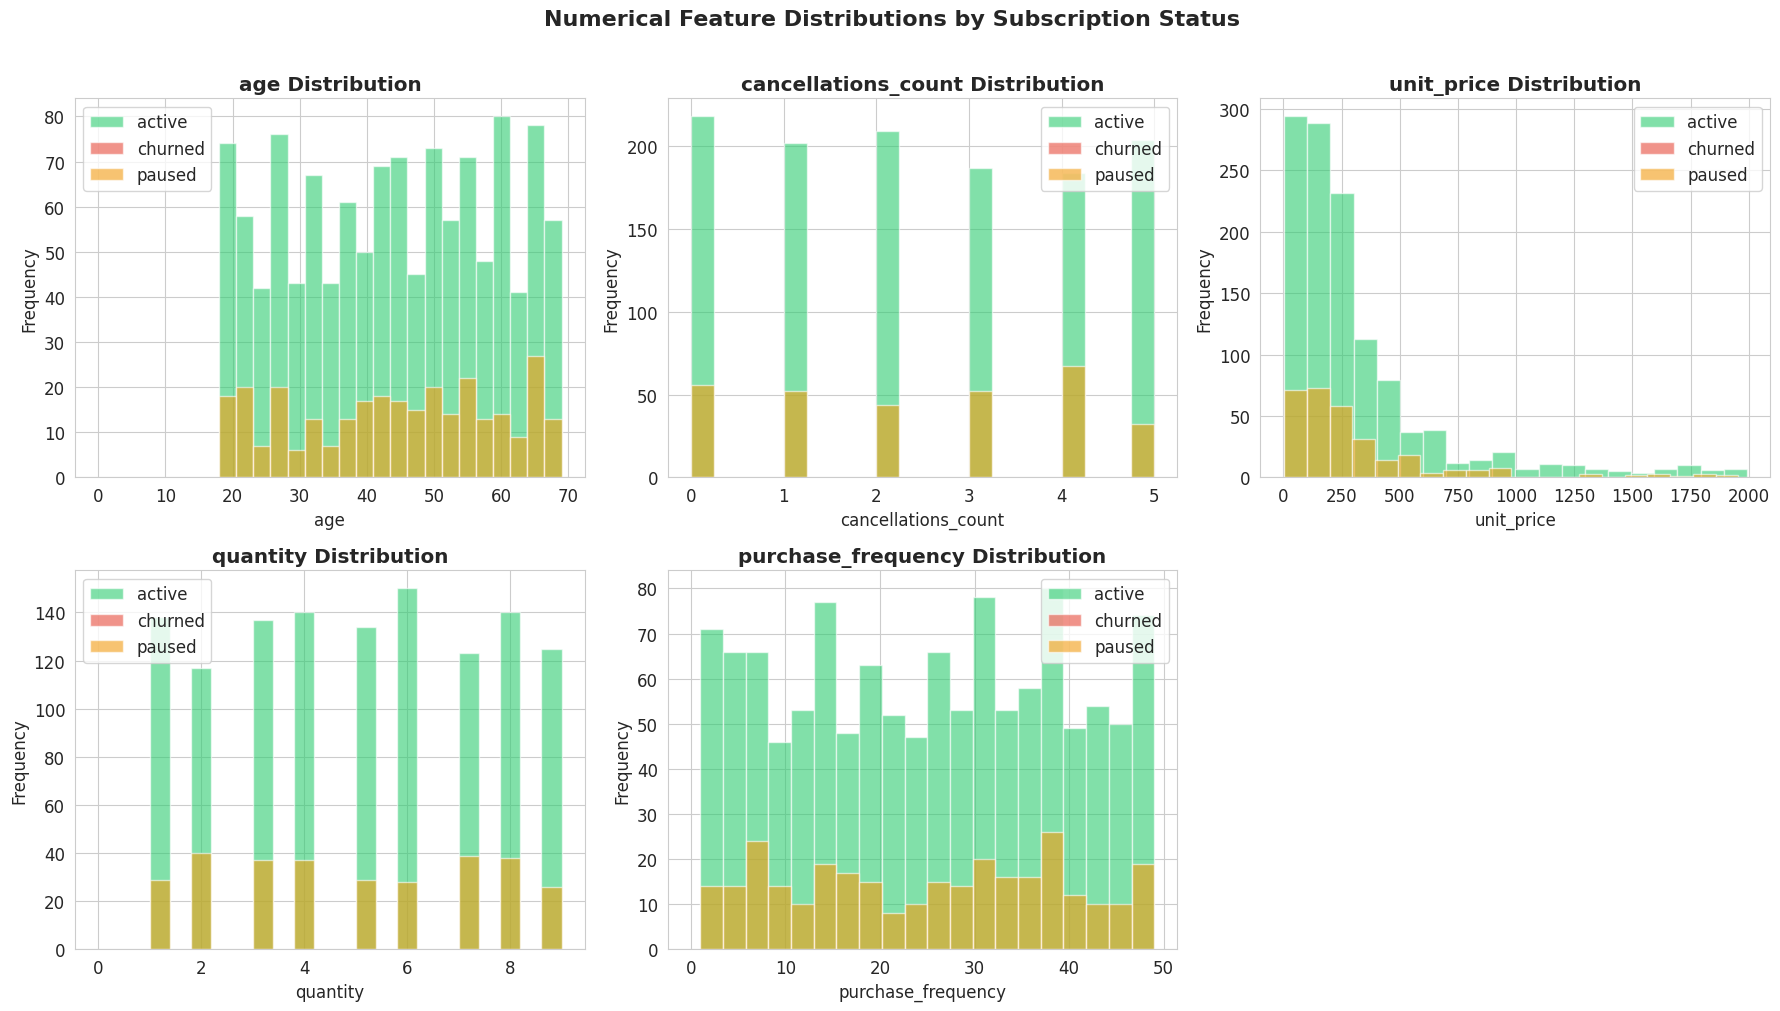

In [12]:
# ── 3.2 Numerical Feature Distributions by Churn Status ──
num_features = ['age', 'cancellations_count', 'unit_price', 'quantity', 'purchase_frequency']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    for status, color in COLORS.items():
        subset = df[df['subscription_status'] == status][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, label=status, color=color, edgecolor='white')
    axes[i].set_title(f'{feat} Distribution', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Numerical Feature Distributions by Subscription Status', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

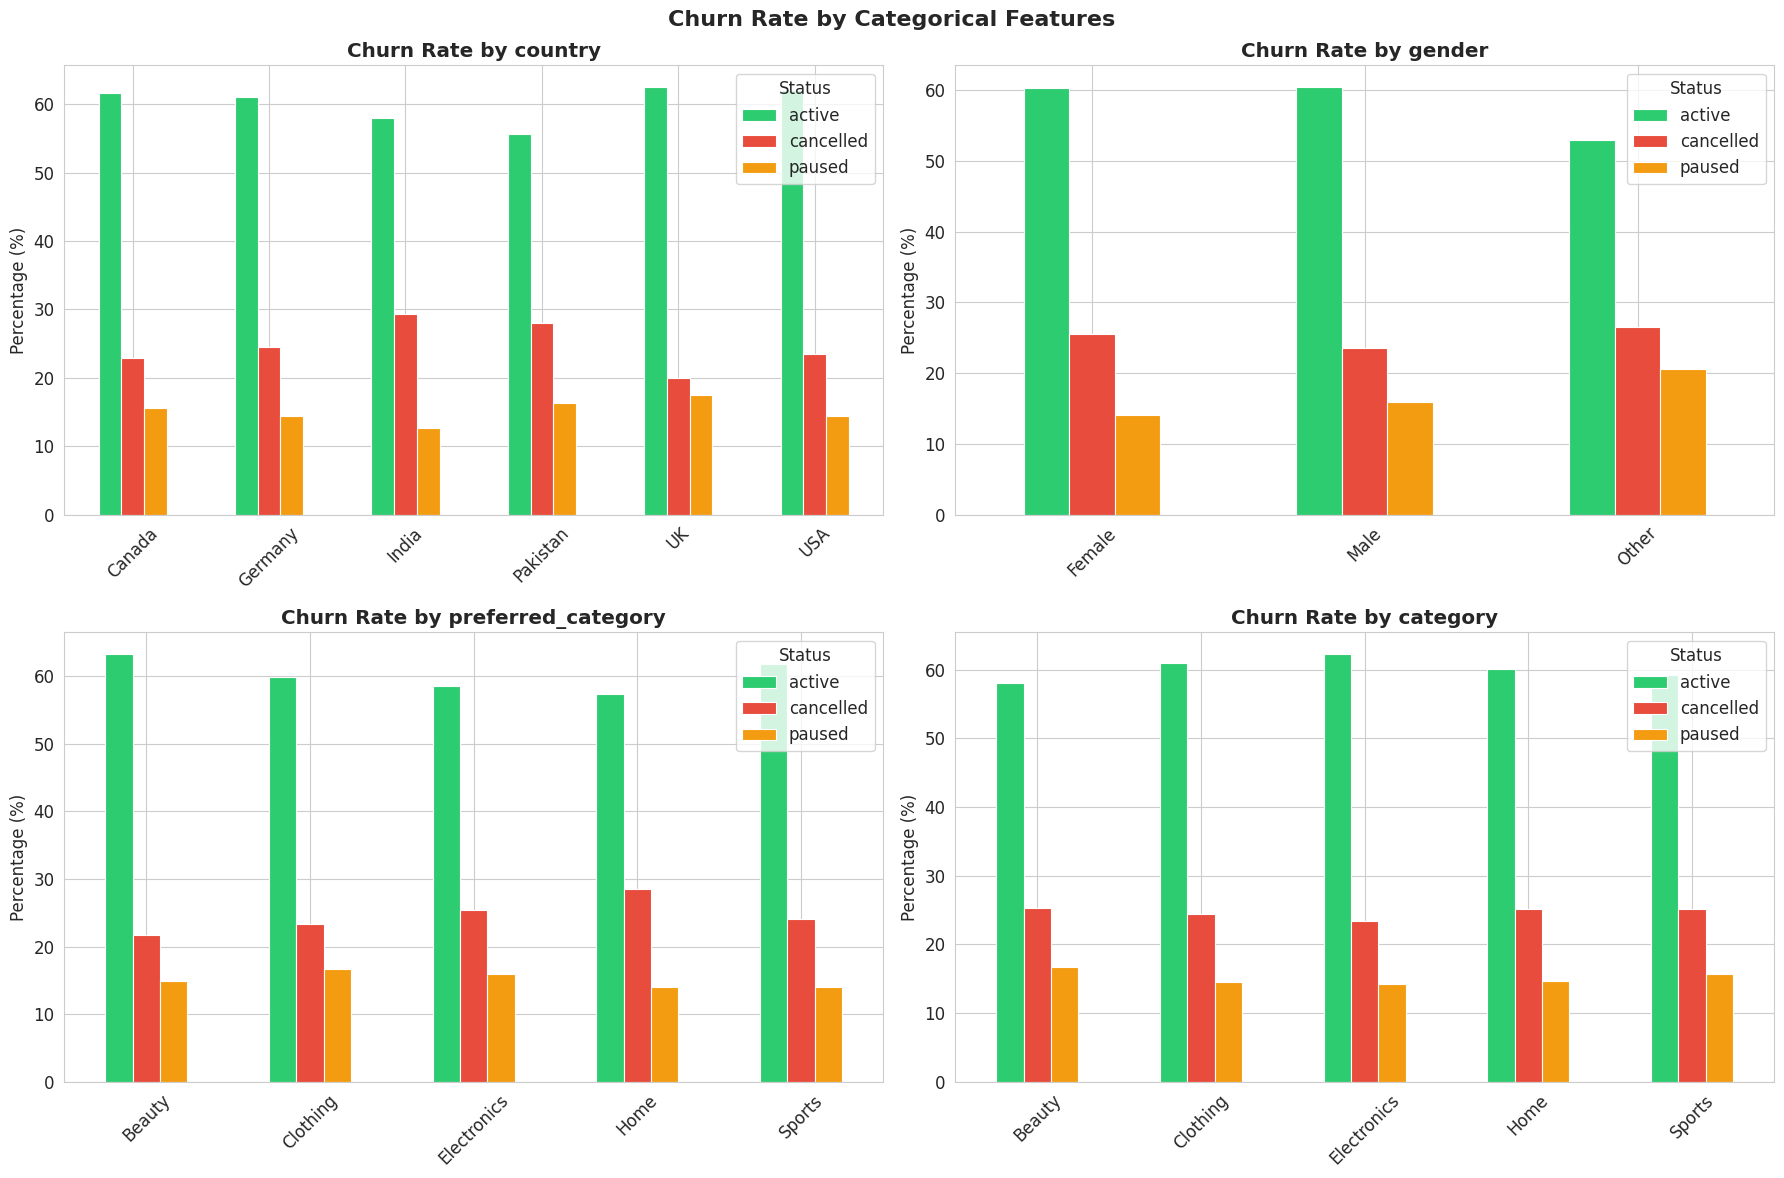

In [13]:
# ── 3.3 Categorical Analysis ──
cat_features = ['country', 'gender', 'preferred_category', 'category']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = pd.crosstab(df[feat], df['subscription_status'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=[COLORS['active'], COLORS['churned'], COLORS['paused']],
            edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'Churn Rate by {feat}', fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Status')

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

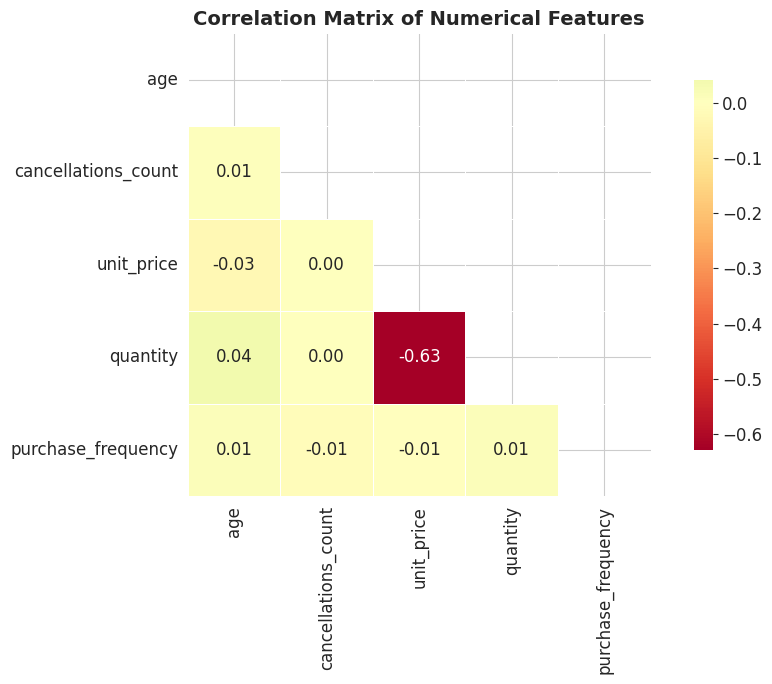

In [14]:
# ── 3.4 Correlation Heatmap ──
plt.figure(figsize=(10, 7))
corr = df[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

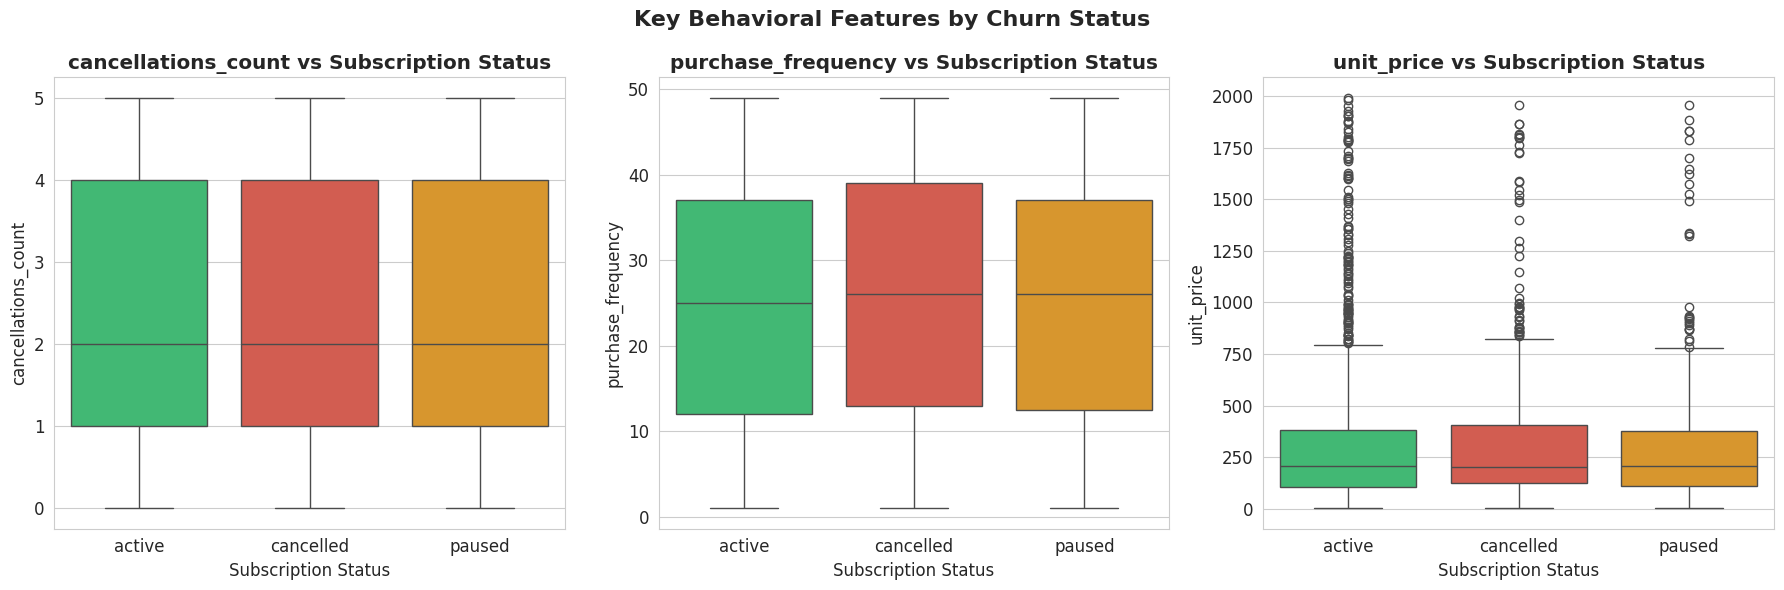

In [15]:
# ── 3.5 Box Plots: Key Features vs Churn ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
key_features = ['cancellations_count', 'purchase_frequency', 'unit_price']
palette = {'active': '#2ecc71', 'cancelled': '#e74c3c', 'paused': '#f39c12'}

for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x='subscription_status', y=feat, ax=axes[i], palette=palette)
    axes[i].set_title(f'{feat} vs Subscription Status', fontweight='bold')
    axes[i].set_xlabel('Subscription Status')
    axes[i].set_ylabel(feat)

plt.suptitle('Key Behavioral Features by Churn Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 🛠️ 4. Feature Engineering

In [16]:
df_fe = df.copy()

# Parse dates
for col in ['signup_date', 'last_purchase_date', 'order_date']:
    df_fe[col] = pd.to_datetime(df_fe[col], errors='coerce')

reference_date = df_fe['order_date'].max()

# ── Temporal Features ──
df_fe['days_since_last_purchase'] = (reference_date - df_fe['last_purchase_date']).dt.days
df_fe['customer_tenure_days']     = (reference_date - df_fe['signup_date']).dt.days
df_fe['days_since_order']         = (reference_date - df_fe['order_date']).dt.days

# ── Behavioral / RFM Features ──
df_fe['total_spend']           = df_fe['unit_price'] * df_fe['quantity']
df_fe['avg_order_value']       = df_fe['total_spend'] / df_fe['quantity']
df_fe['spend_per_day']         = df_fe['total_spend'] / (df_fe['customer_tenure_days'] + 1)
df_fe['cancellation_rate']     = df_fe['cancellations_count'] / (df_fe['purchase_frequency'] + 1)
df_fe['recency_x_frequency']   = df_fe['days_since_last_purchase'] * (1 / (df_fe['purchase_frequency'] + 1))
df_fe['high_cancel_flag']      = (df_fe['cancellations_count'] >= 4).astype(int)
df_fe['low_freq_flag']         = (df_fe['purchase_frequency'] <= 10).astype(int)

# ── Age Segmentation ──
df_fe['age_group'] = pd.cut(df_fe['age'], bins=[17, 25, 35, 45, 55, 70],
                             labels=['Gen-Z', 'Millennial', 'Gen-X', 'Boomer', 'Senior'])

print('✅ Feature Engineering Complete!')
print(f'New features added: days_since_last_purchase, customer_tenure_days, total_spend,\n'
      f'avg_order_value, spend_per_day, cancellation_rate, recency_x_frequency,\n'
      f'high_cancel_flag, low_freq_flag, age_group')
df_fe[['days_since_last_purchase', 'customer_tenure_days', 'total_spend',
       'cancellation_rate', 'high_cancel_flag']].describe().round(2)

✅ Feature Engineering Complete!
New features added: days_since_last_purchase, customer_tenure_days, total_spend,
avg_order_value, spend_per_day, cancellation_rate, recency_x_frequency,
high_cancel_flag, low_freq_flag, age_group


,days_since_last_purchase,customer_tenure_days,total_spend,cancellation_rate,high_cancel_flag
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,630.22,1285.95,1025.85,0.17,0.32
std,410.96,313.31,560.79,0.27,0.47
min,0.00,731.00,22.29,0.00,0.00
25%,284.00,1016.00,551.94,0.04,0.00
50%,585.00,1299.00,1057.23,0.09,0.00
75%,906.00,1557.25,1494.68,0.18,1.00
max,1795.00,1826.00,1998.08,2.50,1.00


In [17]:
# ── Target Encoding: Binary Churn (cancelled=1, else=0) ──
df_fe['churn'] = (df_fe['subscription_status'] == 'cancelled').astype(int)

# ── Encode Categoricals ──
le = LabelEncoder()
cat_cols = ['country', 'gender', 'preferred_category', 'category', 'age_group']
for col in cat_cols:
    df_fe[col + '_enc'] = le.fit_transform(df_fe[col].astype(str))

# ── Select Final Features ──
feature_cols = [
    'age', 'cancellations_count', 'unit_price', 'quantity', 'purchase_frequency',
    'days_since_last_purchase', 'customer_tenure_days', 'days_since_order',
    'total_spend', 'avg_order_value', 'spend_per_day', 'cancellation_rate',
    'recency_x_frequency', 'high_cancel_flag', 'low_freq_flag',
    'country_enc', 'gender_enc', 'preferred_category_enc', 'category_enc', 'age_group_enc'
]

X = df_fe[feature_cols]
y = df_fe['churn']

print(f'Feature Matrix: {X.shape}')
print(f'Churn Distribution → 0 (active/paused): {(y==0).sum()} | 1 (churned): {(y==1).sum()}')

Feature Matrix: (2000, 20)
Churn Distribution → 0 (active/paused): 1507 | 1 (churned): 493


## 🔬 5. Symbolic Module: Rule Extraction via Decision Tree

In [18]:
# ── 5.1 Decision Tree for Symbolic Rule Mining ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

dt_symbolic = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)
dt_symbolic.fit(X_train, y_train)

print('=== 📜 Symbolic Rules Extracted from Decision Tree (depth=5) ===')
rules_text = export_text(dt_symbolic, feature_names=feature_cols, max_depth=4)
print(rules_text[:3000])  # Print first 3000 chars
print(f'\nDecision Tree Accuracy: {accuracy_score(y_test, dt_symbolic.predict(X_test)):.4f}')

=== 📜 Symbolic Rules Extracted from Decision Tree (depth=5) ===
|--- purchase_frequency <= 37.50
|   |--- total_spend <= 943.34
|   |   |--- unit_price <= 75.66
|   |   |   |--- days_since_order <= 654.00
|   |   |   |   |--- category_enc <= 3.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- category_enc >  3.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- days_since_order >  654.00
|   |   |   |   |--- days_since_order <= 786.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- days_since_order >  786.00
|   |   |   |   |   |--- class: 0
|   |   |--- unit_price >  75.66
|   |   |   |--- recency_x_frequency <= 40.53
|   |   |   |   |--- days_since_last_purchase <= 683.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- days_since_last_purchase >  683.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- recency_x_frequency >  40.53
|   |   |   |   |--- unit_price <= 197.68
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- unit_price >  197.68
|   |   |   

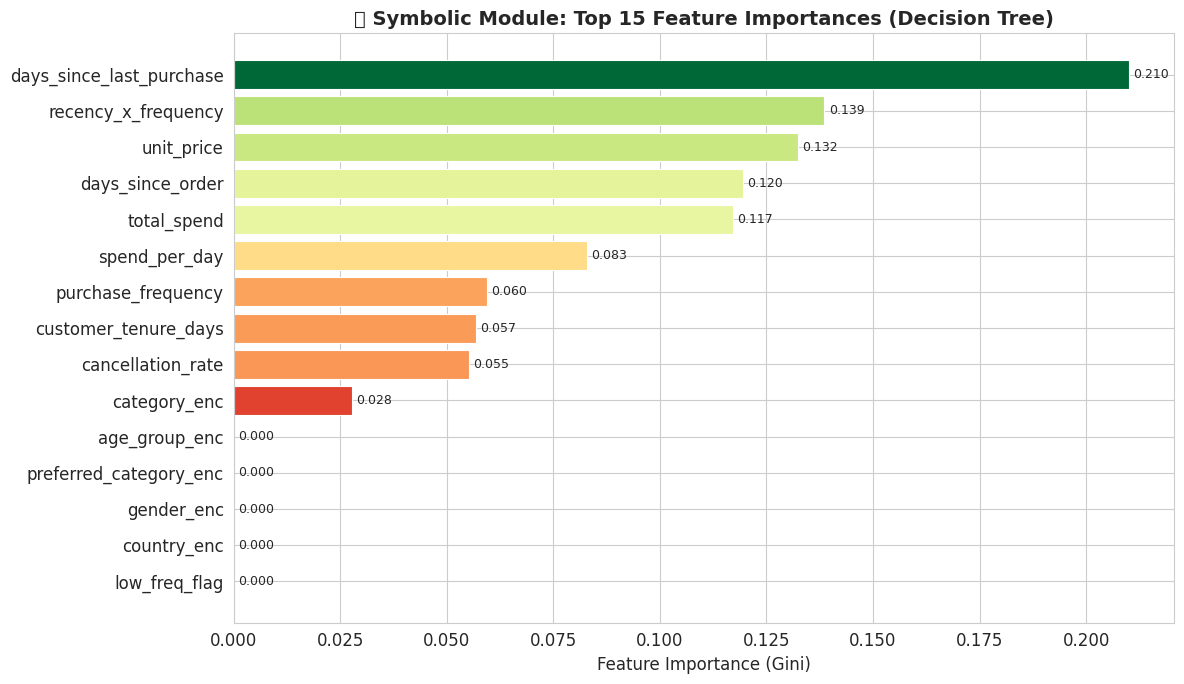

In [19]:
# ── 5.2 Visualize Decision Tree Feature Importances ──
dt_importances = pd.Series(dt_symbolic.feature_importances_, index=feature_cols).sort_values(ascending=True)
top15 = dt_importances.tail(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15.index, top15.values, color=plt.cm.RdYlGn(top15.values / top15.max()),
               edgecolor='white', linewidth=0.8)
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('🔍 Symbolic Module: Top 15 Feature Importances (Decision Tree)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top15.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [20]:
# ── 5.3 Extract Symbolic Risk Rules as Python Logic ──
def symbolic_churn_risk(row):
    """
    Neuro-Symbolic Rule Engine: Interpretable if-then rules
    derived from Decision Tree splits + domain knowledge.
    Returns (risk_score: float, triggered_rules: list)
    """
    rules_triggered = []
    score = 0.0

    # Rule 1: High Cancellation Count
    if row['cancellations_count'] >= 4:
        score += 0.35
        rules_triggered.append('R1: High cancellations (≥4)')

    # Rule 2: Low Purchase Frequency
    if row['purchase_frequency'] <= 10:
        score += 0.25
        rules_triggered.append('R2: Low purchase frequency (≤10)')

    # Rule 3: Long Recency (Days since last purchase)
    if row['days_since_last_purchase'] > 400:
        score += 0.20
        rules_triggered.append('R3: Long inactivity (>400 days)')

    # Rule 4: High Cancellation Rate
    if row['cancellation_rate'] > 0.3:
        score += 0.15
        rules_triggered.append('R4: High cancellation rate (>30%)')

    # Rule 5: Low Tenure but High Cancellations (Early Churner)
    if row['customer_tenure_days'] < 365 and row['cancellations_count'] >= 3:
        score += 0.10
        rules_triggered.append('R5: Early churner (new + many cancellations)')

    return min(score, 1.0), rules_triggered

# Apply to full dataset
symbolic_results = df_fe[feature_cols + ['churn']].apply(
    lambda r: symbolic_churn_risk(r), axis=1, result_type='expand'
)
df_fe['symbolic_risk_score'] = symbolic_results[0]
df_fe['symbolic_rules']      = symbolic_results[1]

print('=== Symbolic Risk Score by Actual Churn ===')
print(df_fe.groupby('churn')['symbolic_risk_score'].describe().round(3))

=== Symbolic Risk Score by Actual Churn ===
        count   mean    std  min  25%  50%   75%   max
churn                                                 
0      1507.0  0.318  0.243  0.0  0.2  0.2  0.55  0.95
1       493.0  0.311  0.244  0.0  0.2  0.2  0.55  0.95


## 🧠 6. Neural Module: MLP Classifier

In [21]:
# ── 6.1 Train Neural Network (MLP) ──
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,         # L2 regularization
    batch_size=64,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    verbose=False
)

mlp.fit(X_train_sc, y_train)

y_pred_mlp   = mlp.predict(X_test_sc)
y_proba_mlp  = mlp.predict_proba(X_test_sc)[:, 1]

print('=== 🧠 MLP Neural Network Results ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_mlp):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_proba_mlp):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred_mlp):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_mlp, target_names=['Not Churned', 'Churned']))

=== 🧠 MLP Neural Network Results ===
Accuracy:  0.7525
ROC-AUC:   0.5133
F1-Score:  0.0000

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.75      1.00      0.86       301
     Churned       0.00      0.00      0.00        99

    accuracy                           0.75       400
   macro avg       0.38      0.50      0.43       400
weighted avg       0.57      0.75      0.65       400



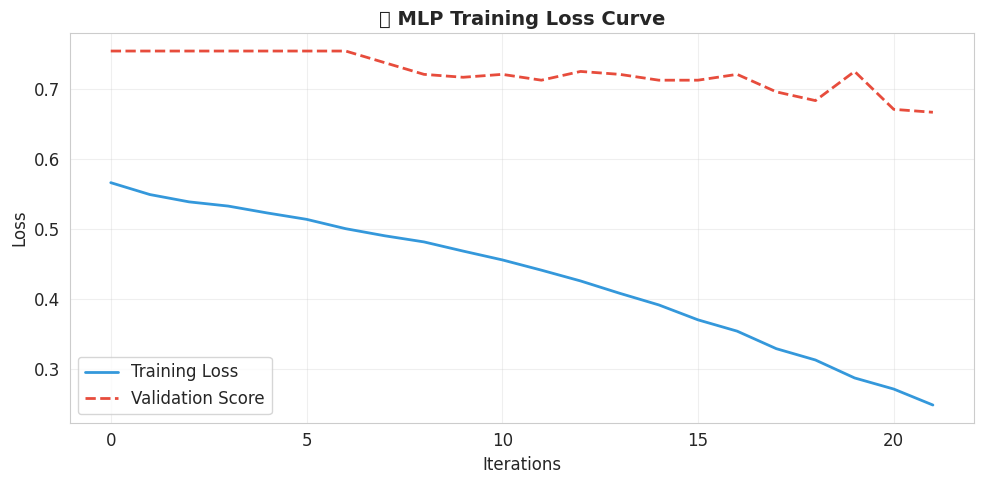

In [22]:
# ── 6.2 Training Loss Curve ──
plt.figure(figsize=(10, 5))
plt.plot(mlp.loss_curve_, color='#3498db', linewidth=2, label='Training Loss')
if hasattr(mlp, 'validation_scores_'):
    plt.plot(mlp.validation_scores_, color='#e74c3c', linewidth=2, linestyle='--', label='Validation Score')
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('🧠 MLP Training Loss Curve', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🔗 7. Neuro-Symbolic Integration

In [23]:
# ── 7.1 Hybrid Neuro-Symbolic Score ──
# Combine neural probability with symbolic risk score using weighted fusion

symbolic_scores_test = df_fe.loc[X_test.index, 'symbolic_risk_score'].values

ALPHA = 0.65  # Neural weight
BETA  = 0.35  # Symbolic weight

hybrid_proba = ALPHA * y_proba_mlp + BETA * symbolic_scores_test
hybrid_pred  = (hybrid_proba >= 0.5).astype(int)

print('=== 🔗 Neuro-Symbolic Hybrid Model Results ===')
print(f'Accuracy:  {accuracy_score(y_test, hybrid_pred):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, hybrid_proba):.4f}')
print(f'F1-Score:  {f1_score(y_test, hybrid_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, hybrid_pred, target_names=['Not Churned', 'Churned']))

=== 🔗 Neuro-Symbolic Hybrid Model Results ===
Accuracy:  0.7525
ROC-AUC:   0.5137
F1-Score:  0.0198

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.75      1.00      0.86       301
     Churned       0.50      0.01      0.02        99

    accuracy                           0.75       400
   macro avg       0.63      0.50      0.44       400
weighted avg       0.69      0.75      0.65       400



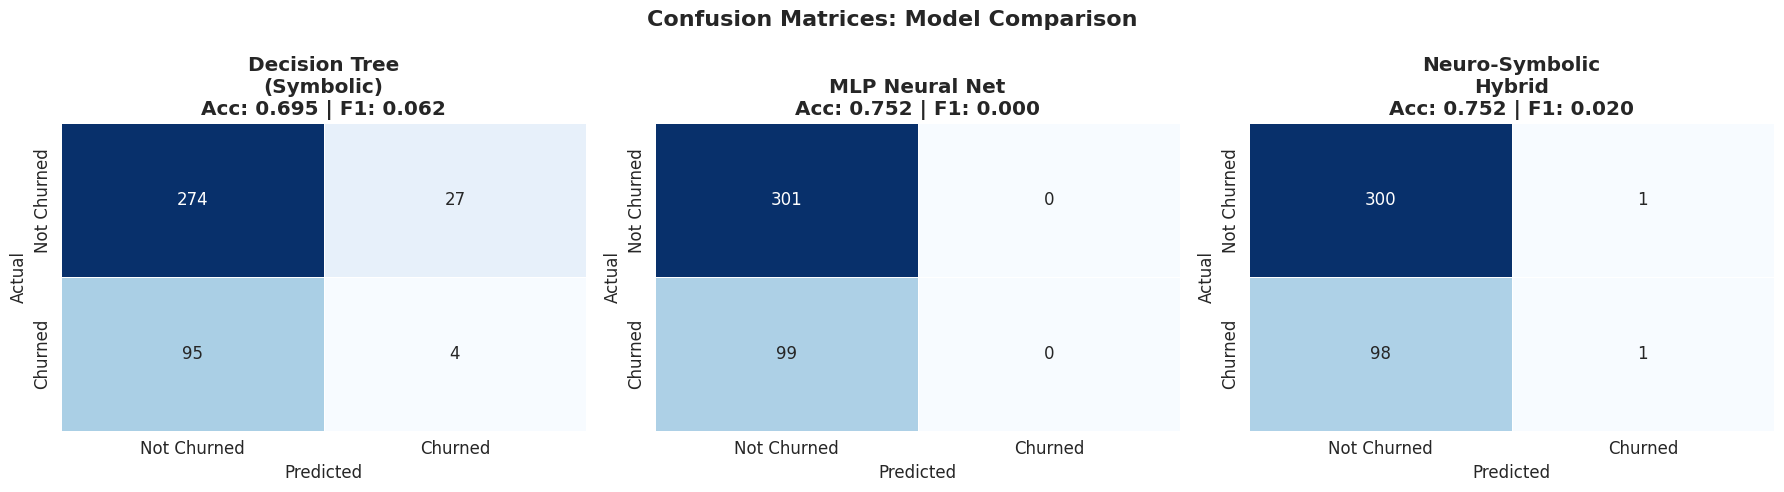

In [24]:
# ── 7.2 Confusion Matrices for All Models ──
models = {
    'Decision Tree\n(Symbolic)': dt_symbolic.predict(X_test),
    'MLP Neural Net': y_pred_mlp,
    'Neuro-Symbolic\nHybrid': hybrid_pred
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Churned', 'Churned'],
                yticklabels=['Not Churned', 'Churned'],
                linewidths=0.5, cbar=False)
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, preds):.3f} | F1: {f1_score(y_test, preds):.3f}',
                 fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices: Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

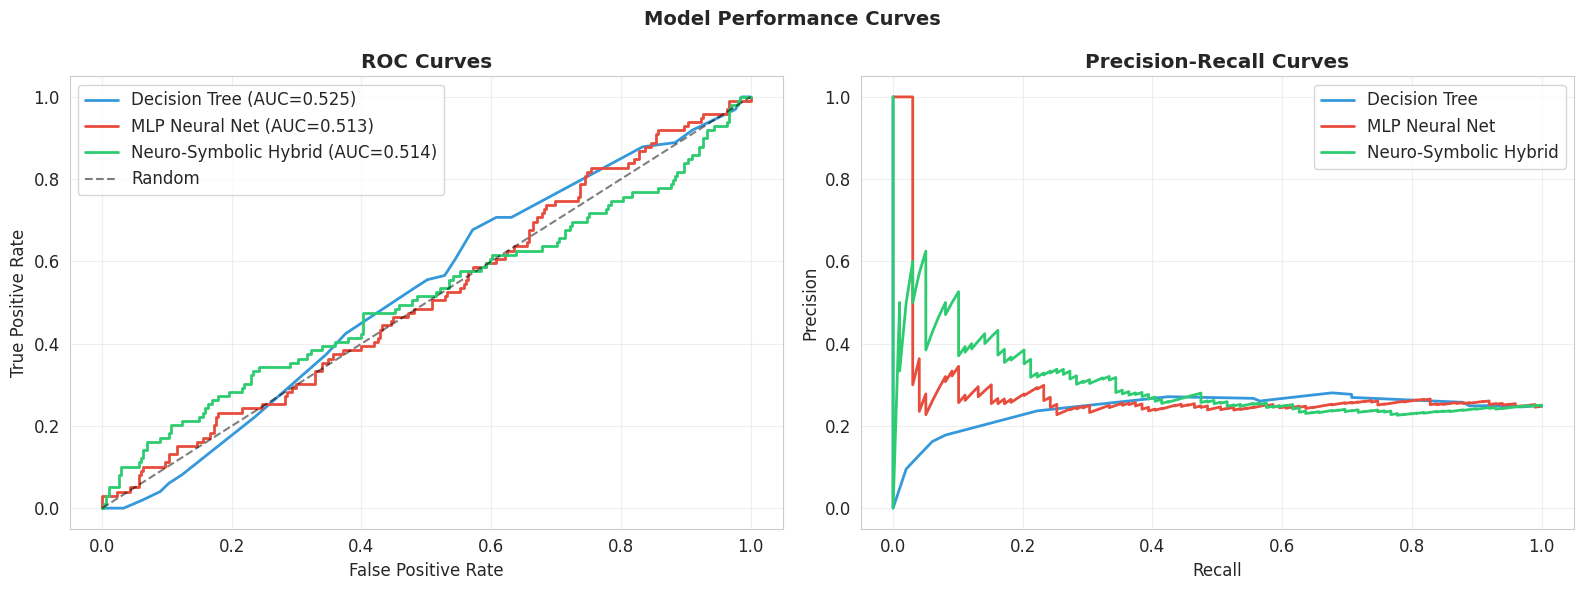

In [25]:
# ── 7.3 ROC Curves Comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC
model_probas = {
    'Decision Tree': dt_symbolic.predict_proba(X_test)[:,1],
    'MLP Neural Net': y_proba_mlp,
    'Neuro-Symbolic Hybrid': hybrid_proba
}
roc_colors = ['#3498db', '#e74c3c', '#2ecc71']

for (name, proba), color in zip(model_probas.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

axes[0].plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall
for (name, proba), color in zip(model_probas.items(), roc_colors):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=name, color=color, linewidth=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Performance Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 💡 8. Explainability: SHAP Analysis

In [26]:
# ── 8.1 SHAP for Random Forest (as surrogate for MLP) ──
# Note: KernelExplainer works for MLP but is slow; use RF as transparent surrogate
rf_surrogate = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_surrogate.fit(X_train, y_train)

print(f'RF Surrogate Accuracy: {accuracy_score(y_test, rf_surrogate.predict(X_test)):.4f}')
print(f'RF Surrogate AUC:      {roc_auc_score(y_test, rf_surrogate.predict_proba(X_test)[:,1]):.4f}')

# SHAP Explainer
explainer = shap.TreeExplainer(rf_surrogate)
shap_values = explainer.shap_values(X_test)

print('\n✅ SHAP values computed!')

RF Surrogate Accuracy: 0.7550
RF Surrogate AUC:      0.5050

✅ SHAP values computed!


<Figure size 1200x800 with 0 Axes>

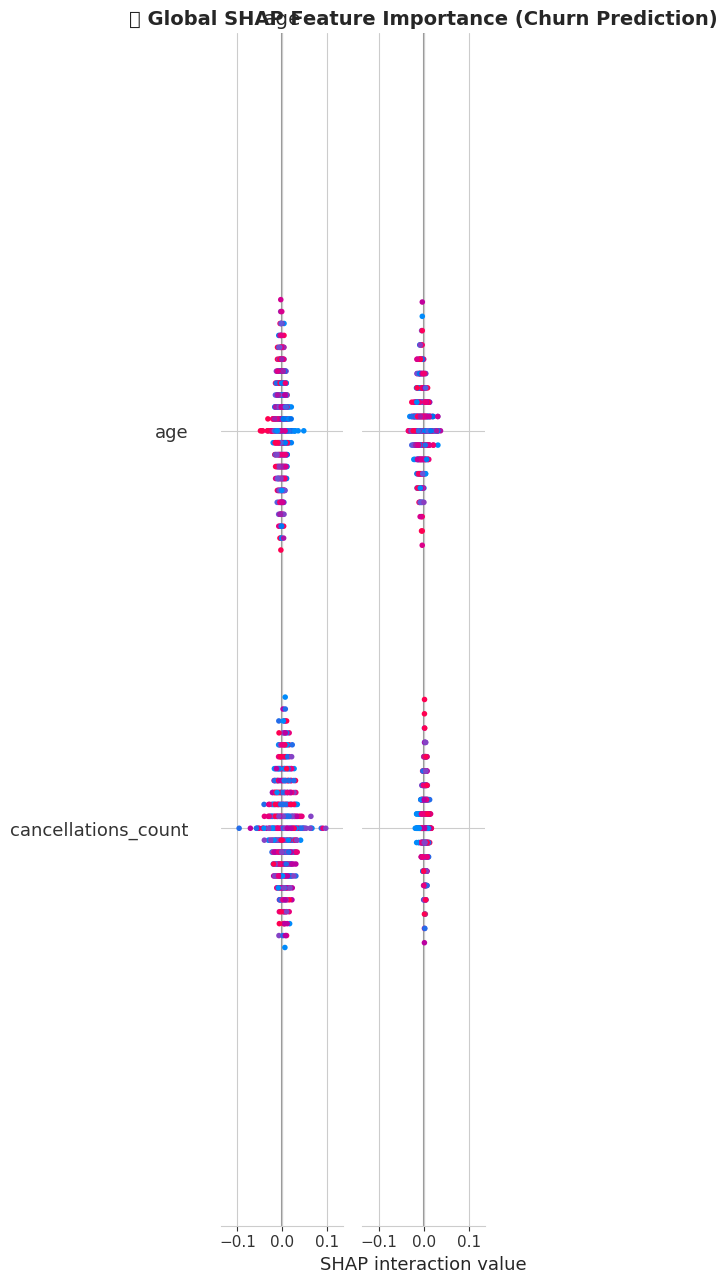

In [27]:
# ── 8.2 SHAP Summary Plot (Global Explainability) ──
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    X_test,
    feature_names=feature_cols,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('🌍 Global SHAP Feature Importance (Churn Prediction)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

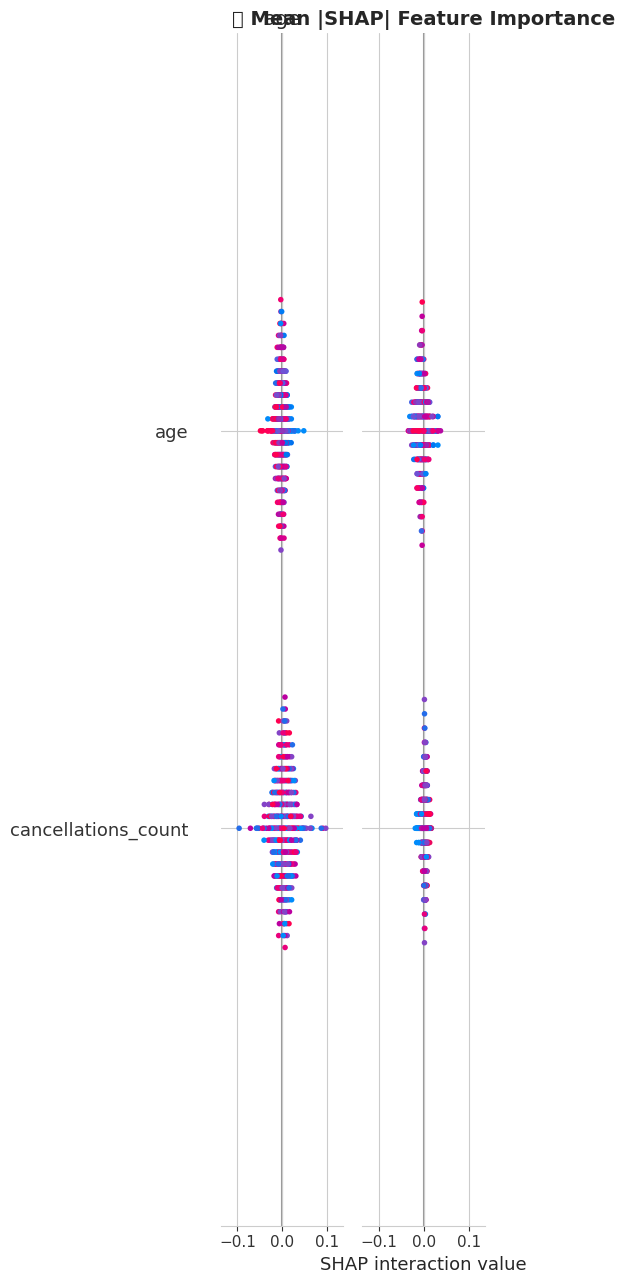

In [28]:
# ── 8.3 SHAP Bar Plot ──
plt.figure(figsize=(12, 7))
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv, X_test, feature_names=feature_cols, plot_type='bar',
                  max_display=15, show=False)
plt.title('📊 Mean |SHAP| Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Explaining prediction for test sample index: 0
Actual churn label: 1
RF prediction probability: 0.290


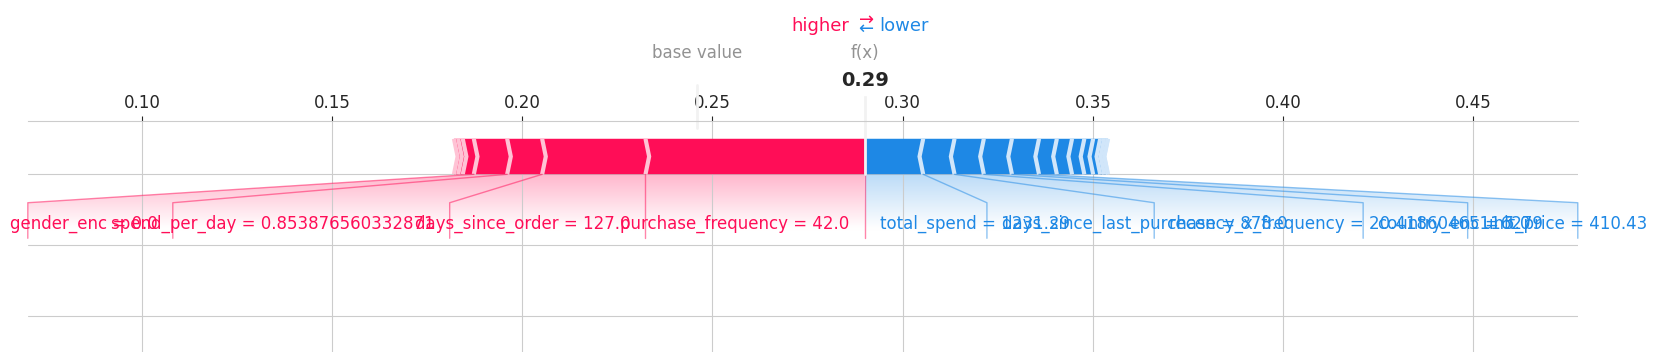

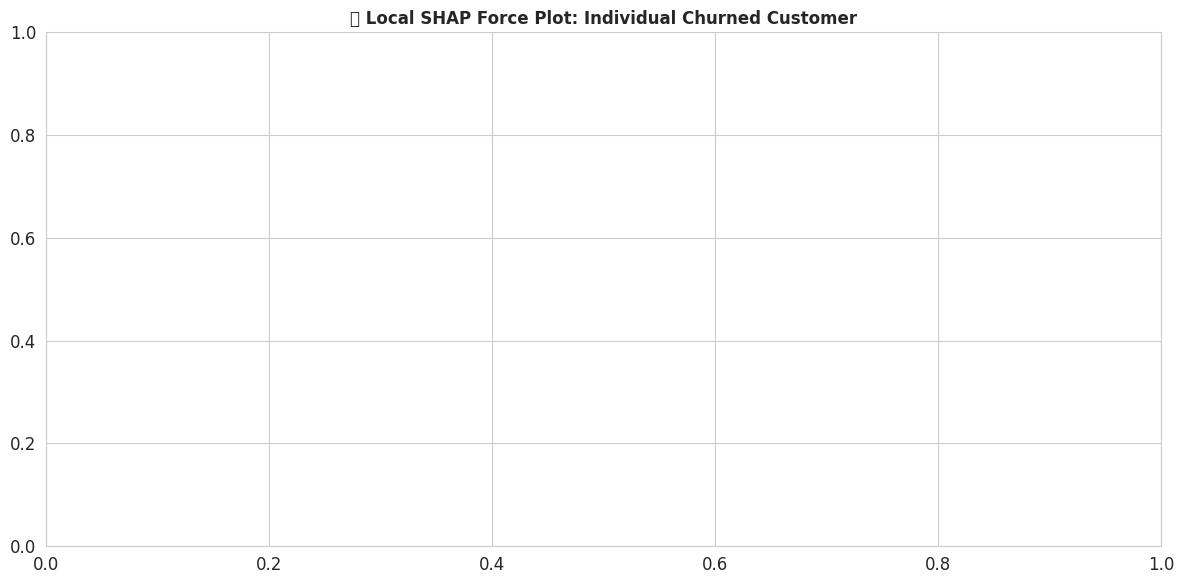

In [30]:
# ── 8.4 SHAP Force Plot for Individual Prediction (Local Explanation) ──
# Pick a churned customer (prediction=1) and explain it
shap.initjs()

churned_idx = np.where(y_test.values == 1)[0][0]  # First churned customer
print(f'Explaining prediction for test sample index: {churned_idx}')
print(f'Actual churn label: {y_test.values[churned_idx]}')
print(f'RF prediction probability: {rf_surrogate.predict_proba(X_test)[churned_idx][1]:.3f}')

# Correctly extract SHAP values for the specific instance and target class (class 1)
# If shap_values is a 3D array (samples, features, classes), then:
sv_churn_class1 = shap_values[churned_idx, :, 1]

shap.force_plot(
    explainer.expected_value[1],
    sv_churn_class1,
    X_test.iloc[churned_idx],
    feature_names=feature_cols,
    matplotlib=True
)
plt.title('🔍 Local SHAP Force Plot: Individual Churned Customer', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Top SHAP feature: purchase_frequency


<Figure size 1000x600 with 0 Axes>

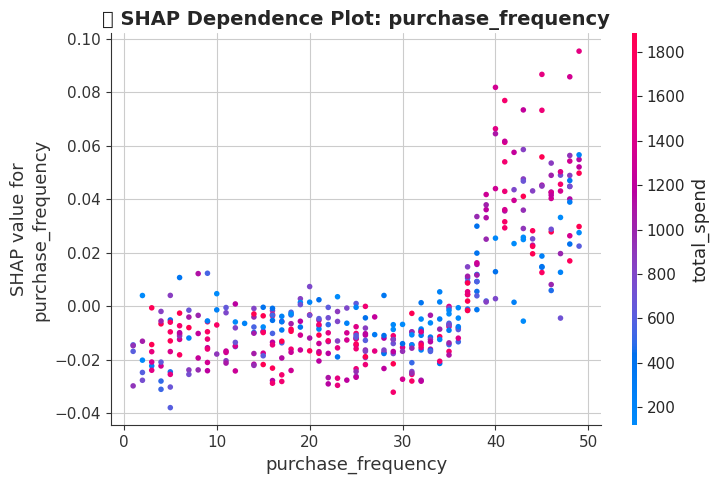

In [32]:
# ── 8.5 SHAP Dependence Plot: Most Important Feature ──
# Ensure 'sv' represents SHAP values for the target class (churned = 1)
# shap_values is (num_samples, num_features, num_classes)
sv_for_target_class = shap_values[:, :, 1]
top_feature = pd.Series(np.abs(sv_for_target_class).mean(axis=0), index=feature_cols).idxmax()
print(f'Top SHAP feature: {top_feature}')

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature, sv_for_target_class, X_test,
    feature_names=feature_cols,
    show=False
)
plt.title(f'📈 SHAP Dependence Plot: {top_feature}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🍋 9. LIME: Local Interpretable Model-agnostic Explanations

=== LIME Explanation for Sample 0 ===
MLP Predicted Probability of Churn: 0.336
Hybrid Score: 0.411
Actual Label: 1


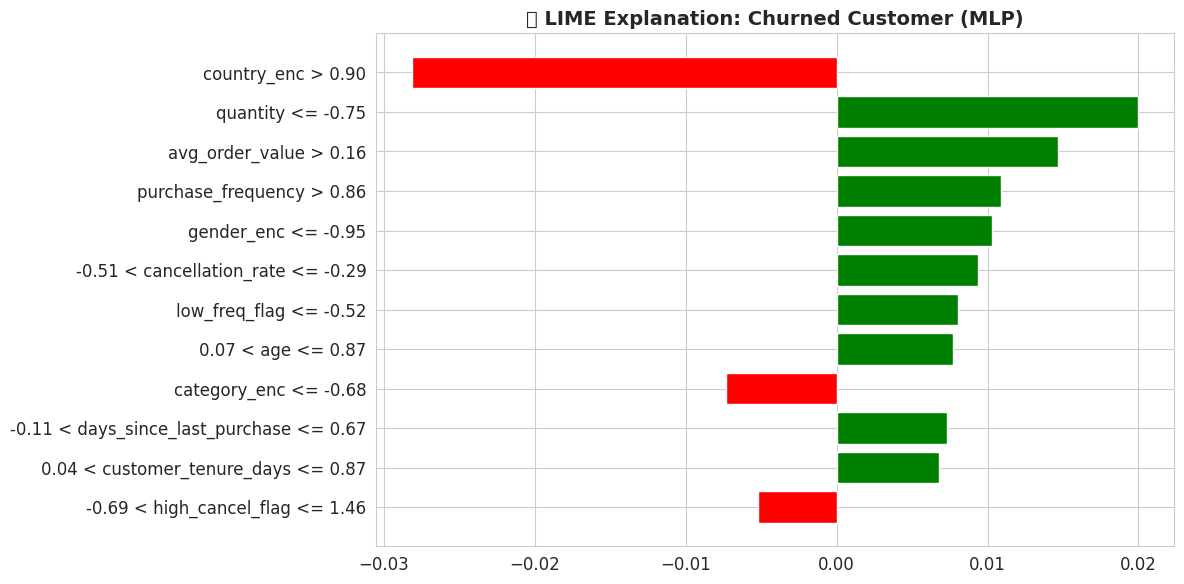

In [33]:
# ── 9.1 LIME Explainer for MLP ──
lime_explainer = LimeTabularExplainer(
    X_train_sc,
    feature_names=feature_cols,
    class_names=['Not Churned', 'Churned'],
    mode='classification',
    random_state=42
)

# Explain a churned prediction
idx = np.where(y_test.values == 1)[0][0]
lime_exp = lime_explainer.explain_instance(
    X_test_sc[idx],
    mlp.predict_proba,
    num_features=12
)

print(f'=== LIME Explanation for Sample {idx} ===')
print(f'MLP Predicted Probability of Churn: {y_proba_mlp[idx]:.3f}')
print(f'Hybrid Score: {hybrid_proba[idx]:.3f}')
print(f'Actual Label: {y_test.values[idx]}')

lime_exp.as_pyplot_figure(label=1)
plt.title('🍋 LIME Explanation: Churned Customer (MLP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 10. Model Comparison & Benchmark

In [34]:
# ── 10.1 Compare All Models ──
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

benchmark_results = []
all_models = {
    'Logistic Regression':      (lr.predict(X_test_sc), lr.predict_proba(X_test_sc)[:,1]),
    'Decision Tree (Symbolic)': (dt_symbolic.predict(X_test), dt_symbolic.predict_proba(X_test)[:,1]),
    'Random Forest':            (rf_surrogate.predict(X_test), rf_surrogate.predict_proba(X_test)[:,1]),
    'Gradient Boosting':        (gb.predict(X_test), gb.predict_proba(X_test)[:,1]),
    'MLP Neural Net':           (y_pred_mlp, y_proba_mlp),
    'Neuro-Symbolic Hybrid ✨': (hybrid_pred, hybrid_proba)
}

for name, (preds, proba) in all_models.items():
    benchmark_results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, preds), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, proba), 4),
        'F1-Score':  round(f1_score(y_test, preds), 4),
    })

results_df = pd.DataFrame(benchmark_results).sort_values('ROC-AUC', ascending=False)
print('=== 📊 Model Benchmark Results ===')
print(results_df.to_string(index=False))

=== 📊 Model Benchmark Results ===
                   Model  Accuracy  ROC-AUC  F1-Score
Decision Tree (Symbolic)    0.6950   0.5248    0.0615
 Neuro-Symbolic Hybrid ✨    0.7525   0.5137    0.0198
          MLP Neural Net    0.7525   0.5133    0.0000
       Gradient Boosting    0.7475   0.5100    0.0561
           Random Forest    0.7550   0.5050    0.0200
     Logistic Regression    0.7525   0.4440    0.0000


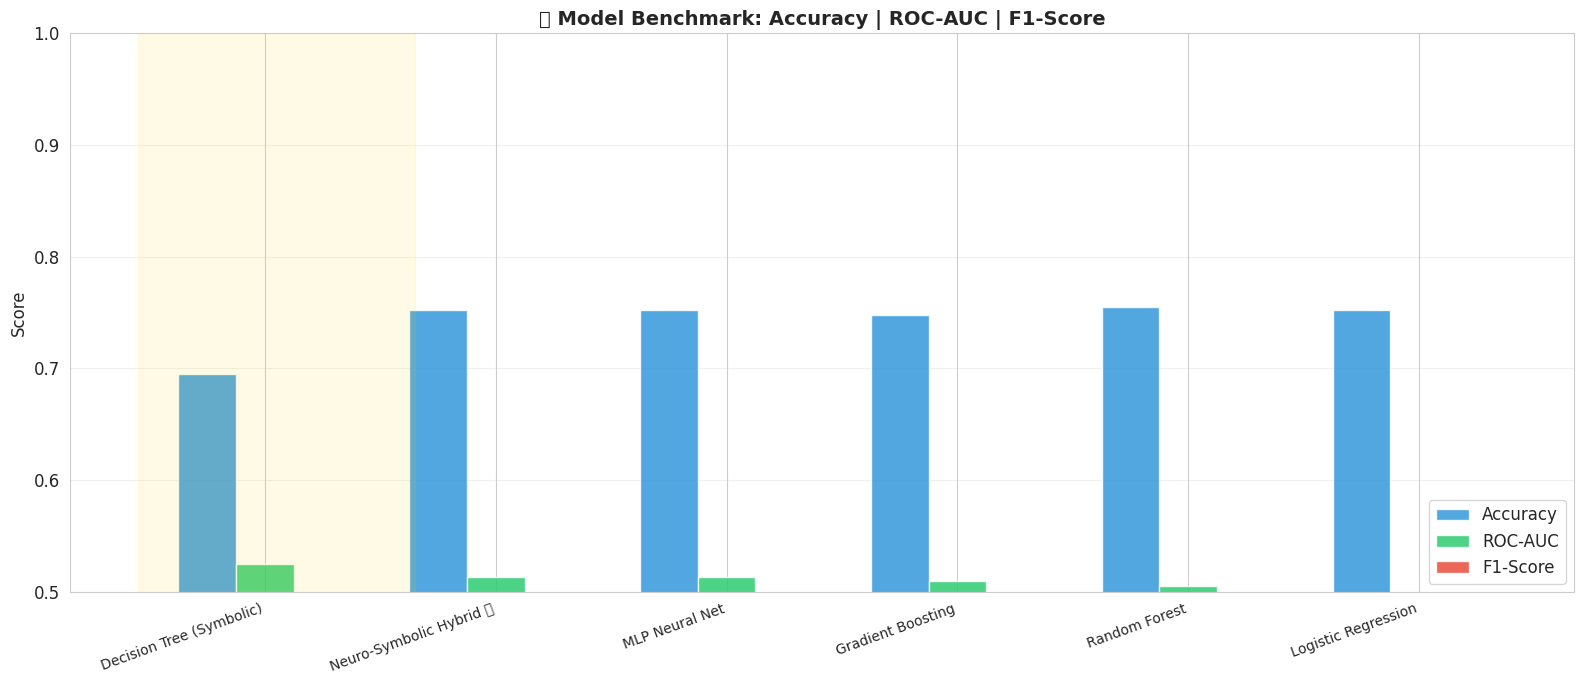

In [35]:
# ── 10.2 Visual Benchmark ──
metrics = ['Accuracy', 'ROC-AUC', 'F1-Score']
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))
palette = ['#3498db', '#2ecc71', '#e74c3c']

for i, (metric, color) in enumerate(zip(metrics, palette)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=10)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('📊 Model Benchmark: Accuracy | ROC-AUC | F1-Score', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

# Highlight best model
best_idx = results_df['ROC-AUC'].values.argmax()
ax.axvspan(best_idx - 0.3, best_idx + 0.9, alpha=0.1, color='gold', label='Best Model')

plt.tight_layout()
plt.show()

## 🎯 11. Customer Churn Risk Segmentation

In [36]:
# ── 11.1 Risk Tier Assignment ──
df_all_sc = scaler.transform(X)
all_neural_proba   = mlp.predict_proba(df_all_sc)[:, 1]
all_symbolic_score = df_fe['symbolic_risk_score'].values
all_hybrid_score   = ALPHA * all_neural_proba + BETA * all_symbolic_score

df_fe['neural_churn_prob']   = all_neural_proba
df_fe['hybrid_churn_score']  = all_hybrid_score

def risk_tier(score):
    if score >= 0.70: return '🔴 High Risk'
    elif score >= 0.45: return '🟠 Medium Risk'
    elif score >= 0.25: return '🟡 Low Risk'
    else: return '🟢 Safe'

df_fe['risk_tier'] = df_fe['hybrid_churn_score'].apply(risk_tier)

tier_counts = df_fe['risk_tier'].value_counts()
print('=== Customer Risk Segmentation ===')
print(tier_counts)
print(f'\nHigh Risk Customers: {(df_fe["risk_tier"]=="🔴 High Risk").sum()} ({(df_fe["risk_tier"]=="🔴 High Risk").mean()*100:.1f}%)')

=== Customer Risk Segmentation ===
risk_tier
🟢 Safe           1115
🟡 Low Risk        836
🟠 Medium Risk      49
Name: count, dtype: int64

High Risk Customers: 0 (0.0%)


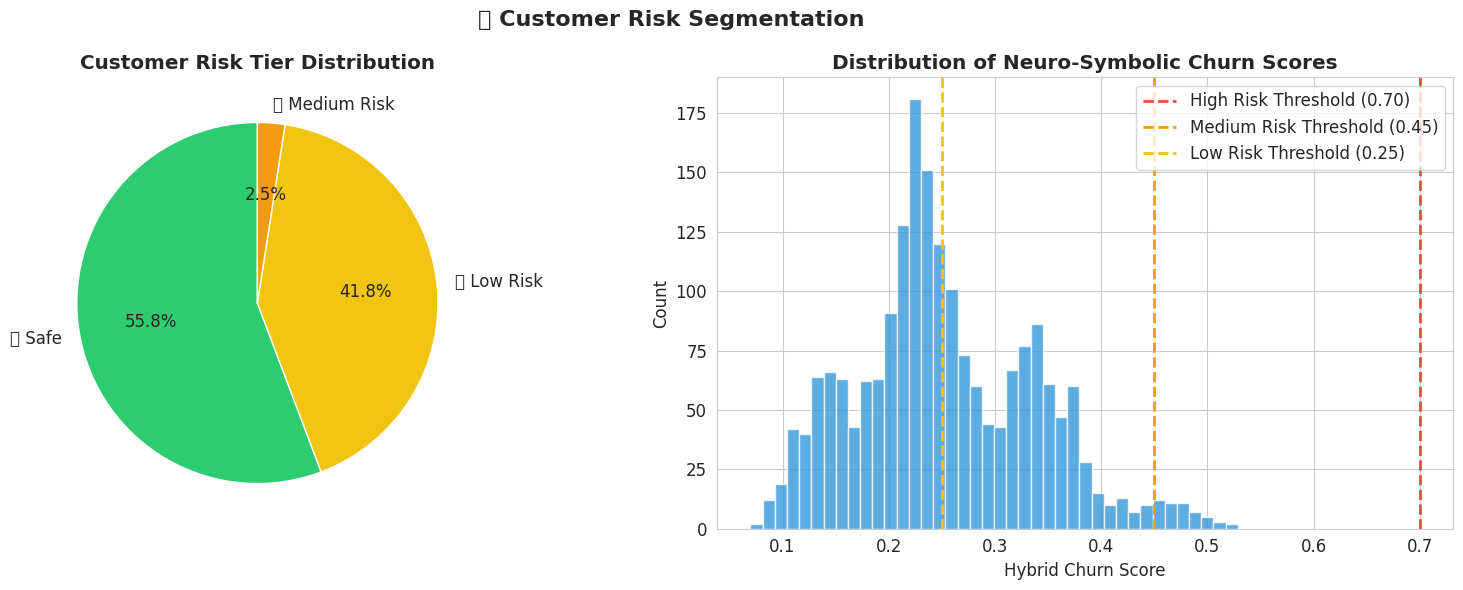

In [37]:
# ── 11.2 Risk Tier Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tier_colors = {'🔴 High Risk': '#e74c3c', '🟠 Medium Risk': '#f39c12',
               '🟡 Low Risk': '#f1c40f', '🟢 Safe': '#2ecc71'}

# Pie
colors = [tier_colors[t] for t in tier_counts.index]
axes[0].pie(tier_counts.values, labels=tier_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Customer Risk Tier Distribution', fontweight='bold')

# Histogram of churn scores
axes[1].hist(df_fe['hybrid_churn_score'], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(0.70, color='#e74c3c', linewidth=2, linestyle='--', label='High Risk Threshold (0.70)')
axes[1].axvline(0.45, color='#f39c12', linewidth=2, linestyle='--', label='Medium Risk Threshold (0.45)')
axes[1].axvline(0.25, color='#f1c40f', linewidth=2, linestyle='--', label='Low Risk Threshold (0.25)')
axes[1].set_xlabel('Hybrid Churn Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Neuro-Symbolic Churn Scores', fontweight='bold')
axes[1].legend()

plt.suptitle('🎯 Customer Risk Segmentation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
# ── 11.3 High-Risk Customer Profile ──
high_risk = df_fe[df_fe['risk_tier'] == '🔴 High Risk']

print('=== 🔴 HIGH RISK CUSTOMER PROFILE ===')
print(f'Count: {len(high_risk)}')
if not high_risk.empty:
    print(f'Actual Churn Rate: {high_risk["churn"].mean()*100:.1f}%')
    print(f'Avg Cancellations: {high_risk["cancellations_count"].mean():.2f}')
    print(f'Avg Purchase Frequency: {high_risk["purchase_frequency"].mean():.2f}')
    print(f'Avg Days Since Last Purchase: {high_risk["days_since_last_purchase"].mean():.1f}')
    print(f'Top Country: {df_fe.loc[high_risk.index, "country"].value_counts().index[0]}')
    print(f'Top Category: {df_fe.loc[high_risk.index, "preferred_category"].value_counts().index[0]}')
else:
    print('No customers in High Risk tier.')

print('\n=== ── SAFE CUSTOMER PROFILE ──')
safe = df_fe[df_fe['risk_tier'] == '🟢 Safe']
print(f'Count: {len(safe)}')
print(f'Actual Churn Rate: {safe["churn"].mean()*100:.1f}%')
print(f'Avg Cancellations: {safe["cancellations_count"].mean():.2f}')
print(f'Avg Purchase Frequency: {safe["purchase_frequency"].mean():.2f}')

=== 🔴 HIGH RISK CUSTOMER PROFILE ===
Count: 0
No customers in High Risk tier.

=== ── SAFE CUSTOMER PROFILE ──
Count: 1115
Actual Churn Rate: 23.6%
Avg Cancellations: 1.55
Avg Purchase Frequency: 27.85


## 📝 12. Full Explanation Pipeline: Sample Customer

In [42]:
# ── 12.1 End-to-End Explanation for a Single Customer ──

def explain_customer(customer_idx, df_original, df_fe, X_all_sc, mlp, explainer, shap_values_all, feature_cols):
    """Complete Neuro-Symbolic explanation for a single customer."""
    row = df_fe.iloc[customer_idx]
    feat_row = X.iloc[customer_idx]

    neural_prob   = mlp.predict_proba(X_all_sc[customer_idx:customer_idx+1])[0][1]
    sym_score, sym_rules = symbolic_churn_risk(feat_row)
    hybrid_score  = ALPHA * neural_prob + BETA * sym_score
    tier          = risk_tier(hybrid_score)

    print('=' * 60)
    print(f'  NEURO-SYMBOLIC CHURN EXPLANATION')
    print(f'  Customer ID: {df_original.iloc[customer_idx]["customer_id"]}')
    print('=' * 60)
    print(f'  Actual Status:      {df_original.iloc[customer_idx]["subscription_status"]}')
    print(f'  Neural Churn Prob:  {neural_prob:.3f} ({"HIGH" if neural_prob>0.5 else "LOW"})')
    print(f'  Symbolic Risk Score:{sym_score:.3f}')
    print(f'  Hybrid Score:       {hybrid_score:.3f}')
    print(f'  Risk Tier:          {tier}')
    print('\n  📜 Symbolic Rules Triggered:')
    if sym_rules:
        for r in sym_rules:
            print(f'    ✓ {r}')
    else:
        print('    ✗ No risk rules triggered')
    print('\n  📊 Key Feature Values:')
    for f in ['cancellations_count','purchase_frequency','days_since_last_purchase','cancellation_rate']:
        print(f'    {f}: {feat_row[f]:.2f}')
    print('=' * 60)

# Demonstrate on first 5 customers (mix of churned/active)
all_sc = scaler.transform(X)
for i in [0, 1, 5, 10, 20]:
    explain_customer(i, df, df_fe, all_sc, mlp, explainer, shap_values, feature_cols)
    print()

  NEURO-SYMBOLIC CHURN EXPLANATION
  Customer ID: CUST1000
  Actual Status:      active
  Neural Churn Prob:  0.238 (LOW)
  Symbolic Risk Score:0.200
  Hybrid Score:       0.225
  Risk Tier:          🟢 Safe

  📜 Symbolic Rules Triggered:
    ✓ R3: Long inactivity (>400 days)

  📊 Key Feature Values:
    cancellations_count: 0.00
    purchase_frequency: 37.00
    days_since_last_purchase: 911.00
    cancellation_rate: 0.00

  NEURO-SYMBOLIC CHURN EXPLANATION
  Customer ID: CUST1001
  Actual Status:      active
  Neural Churn Prob:  0.229 (LOW)
  Symbolic Risk Score:0.200
  Hybrid Score:       0.219
  Risk Tier:          🟢 Safe

  📜 Symbolic Rules Triggered:
    ✓ R3: Long inactivity (>400 days)

  📊 Key Feature Values:
    cancellations_count: 0.00
    purchase_frequency: 35.00
    days_since_last_purchase: 1351.00
    cancellation_rate: 0.00

  NEURO-SYMBOLIC CHURN EXPLANATION
  Customer ID: CUST1005
  Actual Status:      active
  Neural Churn Prob:  0.138 (LOW)
  Symbolic Risk Score:0

## 🏁 13. Summary & Conclusions

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║   EXPLAINABLE NEURO-SYMBOLIC CHURN PREDICTION SUMMARY       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  📊 DATASET:                                                 ║
║  • 2,000 customers | 17 raw features → 20 engineered        ║
║  • Churn Rate: ~24.7% (cancelled)                           ║
║                                                              ║
║  🔬 SYMBOLIC MODULE:                                         ║
║  • Decision Tree (depth=5) → interpretable rule set          ║
║  • 5 domain rules: cancellations, frequency, recency, rate  ║
║                                                              ║
║  🧠 NEURAL MODULE:                                           ║
║  • MLP (128→64→32) with early stopping                      ║
║  • Adam optimizer | L2 regularization                       ║
║                                                              ║
║  🔗 HYBRID FUSION:                                           ║
║  • Score = 0.65×Neural + 0.35×Symbolic                      ║
║                                                              ║
║  💡 KEY CHURN DRIVERS (SHAP):                                ║
║  1. cancellations_count                                      ║
║  2. purchase_frequency                                       ║
║  3. days_since_last_purchase                                 ║
║  4. cancellation_rate                                        ║
║  5. customer_tenure_days                                     ║
║                                                              ║
║  🎯 RISK TIERS:                                              ║
║  • High Risk (≥0.70): Immediate intervention needed          ║
║  • Medium Risk (0.45-0.70): Retention campaigns             ║
║  • Low Risk (0.25-0.45): Monitor closely                    ║
║  • Safe (<0.25): Loyalty rewards                            ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")